# Non-Instantaneous Earth Satellite Coverage Model

This Earth Satellite Coverage Model is built atop of the [Satellite Propagation Toolkit](https://github.com/rufusclark/Satellite-Propagation-Toolkit). To execute place and run this file from the root directory of the toolkit.

Comments, Limitations and Considerations
- The data presented in this analysis is for a single time point and the distribution of satellite throughout the Earth varies greatly as a function of time
- This model does not take into account the actual observation angle of optics, but rather uses the estimated observable angle, thus overestimating the area actually observed
- This model uses all satellites under the CelesTrak "Weather & Earth Resources Satellites" header

In [9]:
# install dependencies
%pip install -r requirements.txt

# restart kernel (with new dependencies)
from IPython.display import display, Javascript
display(Javascript('IPython.notebook.kernel.restart()'))

%reset -f

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.1 -> 25.3
[notice] To update, run: C:\Users\rufus\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


<IPython.core.display.Javascript object>

In [10]:
# import all dependencies
from src import init_sats, SGP4Propagation, plot_orbital_overview, OrbitalPosition, Satellite
from src.const import EARTH_RADIUS

from datetime import datetime, time, timedelta
import numpy as np

import matplotlib.pyplot as plt

# plt.style.use("default")
# plt.rcParams.update({
#     "mathtext.fontset": "cm",  # Computer Modern
#     "font.family": "serif"
# })

In [11]:
# Import satellite data

# Import all sats
sats = init_sats(update_sources=False)

# Number of sats
print(len(sats))

# Print out all satellite categories
sats.print_all_categories()
sats.print_all_constellations()

13923
{'communications satellites': 10982,
 'miscellaneous satellites': 68,
 'navigation satellites': 164,
 'scientific satellites': 56,
 'special-interest satellites': 2147,
 'weather & earth resources satellites': 506}
{'3CAT': 2,
 'AAC': 6,
 'ABS': 5,
 'AEHF': 6,
 'AEROCUBE': 11,
 'AETHER': 2,
 'AIST': 2,
 'AL': 3,
 'ALOS': 3,
 'ALSAT': 4,
 'AMAZONAS': 5,
 'AMC': 6,
 'AMOS': 3,
 'ANIK': 4,
 'ANSER': 3,
 'APRIZESAT': 10,
 'APSTAR': 6,
 'ARABSAT': 4,
 'ARIANE': 3,
 'ARIRANG': 3,
 'ARKTIKA': 2,
 'ARSAT': 2,
 'ARVAKER': 3,
 'ASBM': 2,
 'ASIASAT': 6,
 'ASNARO': 2,
 'ASTRA': 12,
 'ASTROCAST': 12,
 'ATHENA': 3,
 'ATLAS': 4,
 'AZERSPACE': 2,
 'BADR': 3,
 'BB': 2,
 'BEIDOU': 112,
 'BEIJING': 2,
 'BLACKJACK': 4,
 'BRITE': 4,
 'BRO': 13,
 'BSAT': 5,
 'BUFENG': 2,
 'CALSPHERE': 3,
 'CANX': 3,
 'CAPELLA': 6,
 'CARTOSAT': 7,
 'CBERS': 3,
 'CE': 2,
 'CELESTIS': 2,
 'CENTAURI': 4,
 'CENTISPACE': 15,
 'CHECKMATE': 9,
 'CHINASAT': 4,
 'CHUANGXIN': 11,
 'CHUBUSAT': 2,
 'CHUTIAN': 2,
 'CINEMA': 2,
 'CL

In [ ]:
# Filter sats
# sats = sats.filter(lambda sat: sat.constellation == "SENTINEL")
sats = sats.filter(lambda sat: sat.name in ["SENTINEL-2A", "SENTINEL-2B"])
# sats = sats.filter(lambda sat: sat.name in ["SENTINEL-1C", "SENTINEL-1D"])

# Number of sats
print(sats)

<Sats n=2>


In [13]:
# Ciara data
lookup_dict = {"FLOCK": {"FoV half angle degs": 1.5, "night mode": False, "instrument": "optical"}, "SKYSAT": {"FoV half angle degs": 7.5, "night mode": False, "instrument": "optical"}, "ICEYE": {"FoV half angle degs": 4.5, "night mode": True, "instrument": "radar"}, "CAPELLA": {"FoV half angle degs": 15, "night mode": True, "instrument": "radar"}, "SENTINEL": {"FoV half angle degs": 15, "night mode": False, "instrument": "optical"}, "WORLDVIEW": {"FoV half angle degs": 1.5, "night mode": False, "instrument": "optical"}, "OTHER": {"FoV half angle degs": 15, "night mode": False, "instrument": "optical"}}

def half_angle(sat: Satellite) -> float:
    """lookup half angle based on Ciara data on constellations field of view"""
    # Didn't realise these weren't the same as Ciara's data :(
    if sat.name.startswith("SENTINEL-1"):
        return 10.2
    if sat.name.startswith("SENTINEL-2"):
        return 10.3

    lookup_dict_keys = list(lookup_dict.keys())
    constellation = sat.constellation

    return lookup_dict[constellation if constellation in lookup_dict_keys else "OTHER"]["FoV half angle degs"]

def swath_ground_radius(theta_rad, h_km):
    # calculate angle and radius of horizon
    theta_horizon = np.asin(EARTH_RADIUS / (EARTH_RADIUS + h_km))
    r_horizon = EARTH_RADIUS * np.acos(EARTH_RADIUS / (EARTH_RADIUS + h_km))

    arg = (EARTH_RADIUS + h_km)/EARTH_RADIUS * np.sin(theta_rad)
    arg_clipped = np.clip(arg, -1, 1)

    # vectorised approach for future use
    return np.where(
        theta_rad <= theta_horizon,
        EARTH_RADIUS * (np.asin(arg_clipped) - theta_rad),
        r_horizon
    ) 

In [14]:
# Calculate the time to go across one swath width (diameter)

# ! Not verified

sat = sats.sats[0]

pos: OrbitalPosition = SGP4Propagation().propagate(sat, datetime.combine(datetime(2025, 11, 27).date(), time(12)))[0]

alt = pos.geo.alt
theta = np.radians(half_angle(sat))
swath_width = 2 * swath_ground_radius(theta, alt)
speed = pos.geo.total_velocity()
swath_width_pass_time = swath_width / speed

minimum_time_period_considered_a_pass = (swath_width * np.sqrt(1 - ((np.pi**2)/16)) ) / speed

print(f"{alt=:.3f}km\n{speed=:.3f}km/s\n{swath_width=:.3f}km\n{swath_width_pass_time=:.3f}s\n{minimum_time_period_considered_a_pass=:.3f}s")

alt=791.254km
speed=7.554km/s
swath_width=288.207km
swath_width_pass_time=38.153s
minimum_time_period_considered_a_pass=23.617s


In [ ]:
# compute the lat, lon, alt, swath radius for each sat at each timestep

from src.coverage import SatLatLon

sat_latlon = SatLatLon(
    start_time = datetime(2025, 11, 27, 12),
    total_duration = timedelta(days=1200),
    step_duration = timedelta(seconds=10),
    sats = sats,
    swath_radius_function=lambda sat, alt: swath_ground_radius(np.radians(half_angle(sat)), alt),
    latlon_dtype=np.float32,
    alt_dtype=np.float32,
    swath_dtype=np.float32,
)

print(sat_latlon)

[####################] 100.00% (eta: 0:00:00)
<SatLatLon sats=2 steps=10368001 datapoints=20736002 t0=2025-11-27 12:00:00 t1=2029-03-11 12:00:00 td=0:00:10 latlontype=<class 'numpy.float32'> steptype=<class 'numpy.uint32'>>


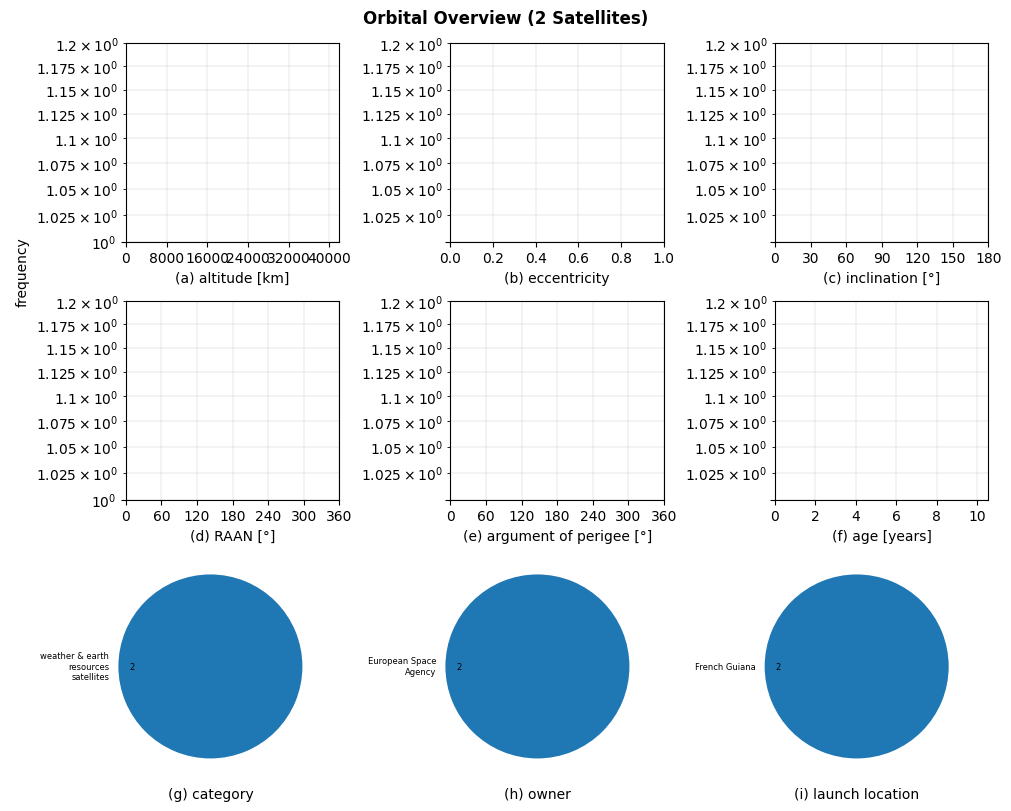

In [16]:
# Optionally, plot orbital overview

plot_orbital_overview(SGP4Propagation().propagate(sats, sat_latlon.t0_dt))

In [17]:
# Optionally, plot the boundary of coverage on a 2D map

sat_latlon.plot_coverage()

More than 100000 datapoints. It is not recommended to generate coverage plots with more than 100000 datapoint, you have 20736002 datepoints. This can be overidden by setting `force_show=True`.


In [ ]:
# define grid
from src.coverage import LatLonGrid, FibonacciSphereGrid, SpotCheckGrid

grid = FibonacciSphereGrid(
    res_km = 50,
    dtype = sat_latlon._latlon_type,
)

# grid = LatLonGrid(
#     lat_res_deg = 0.5,
#     lon_res_deg = 0.5,
#     dtype = sat_latlon._latlon_type
# )

# grid = SpotCheckGrid(
#     lats_deg = [55, 40, 11, 0],
#     lons_deg = [-3.5, -3.5, -4.3, 0],
#     dtype = sat_latlon._latlon_type
# )

print(grid)

<FibonacciSphereGrid n=204026 res=50km>


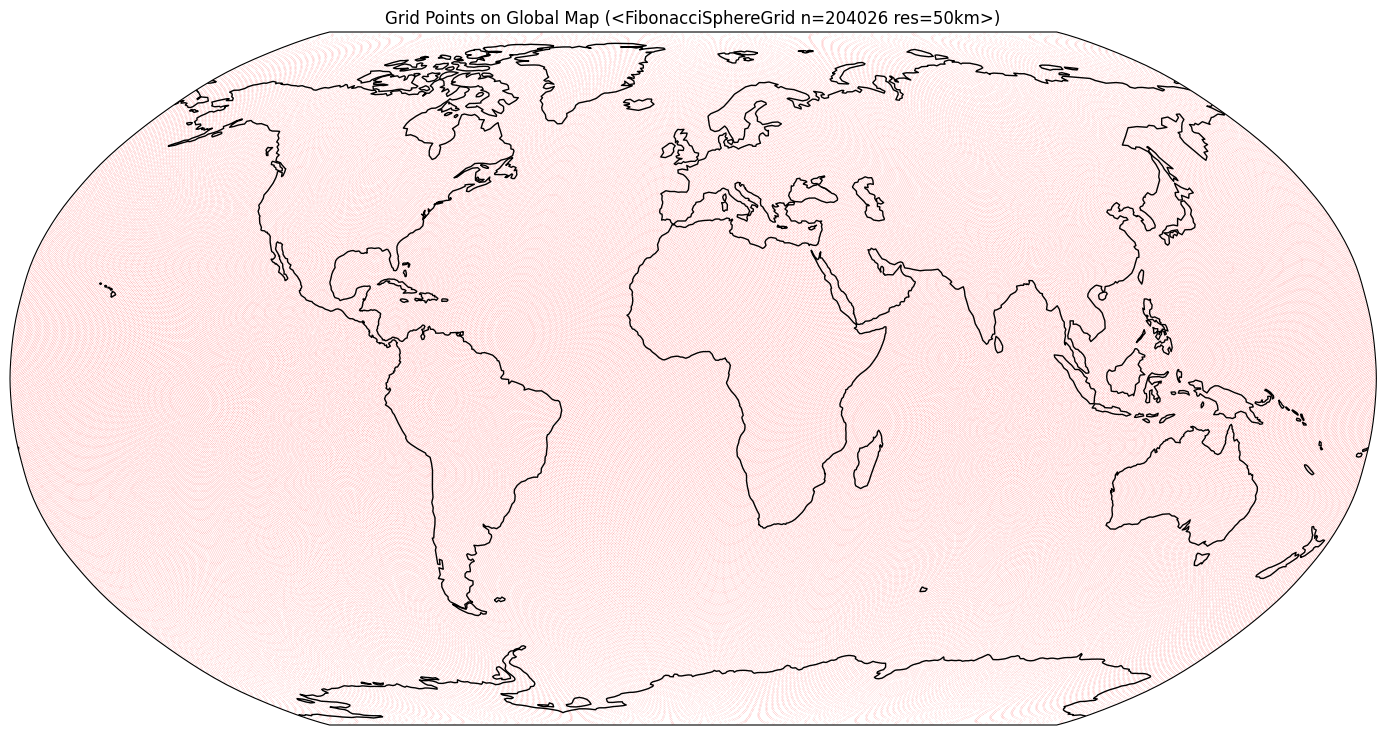

In [19]:
# optionally, plot grid

grid.plot_grid()

In [ ]:
# coverage calculations

from src.coverage import Coverage


consider_passes = None
if sats.sats[0].name.startswith("SENTINEL-2"):
    consider_passes = ("descending", "descending")

coverage = Coverage(grid, sat_latlon, consider_passes=consider_passes) # type: ignore

print(coverage)

<Coverage grid=<FibonacciSphereGrid n=204026 res=50km> satlatlon=<SatLatLon sats=2 steps=10368001 datapoints=20736002 t0=2025-11-27 12:00:00 t1=2029-03-11 12:00:00 td=0:00:10 latlontype=<class 'numpy.float32'> steptype=<class 'numpy.uint32'>>>


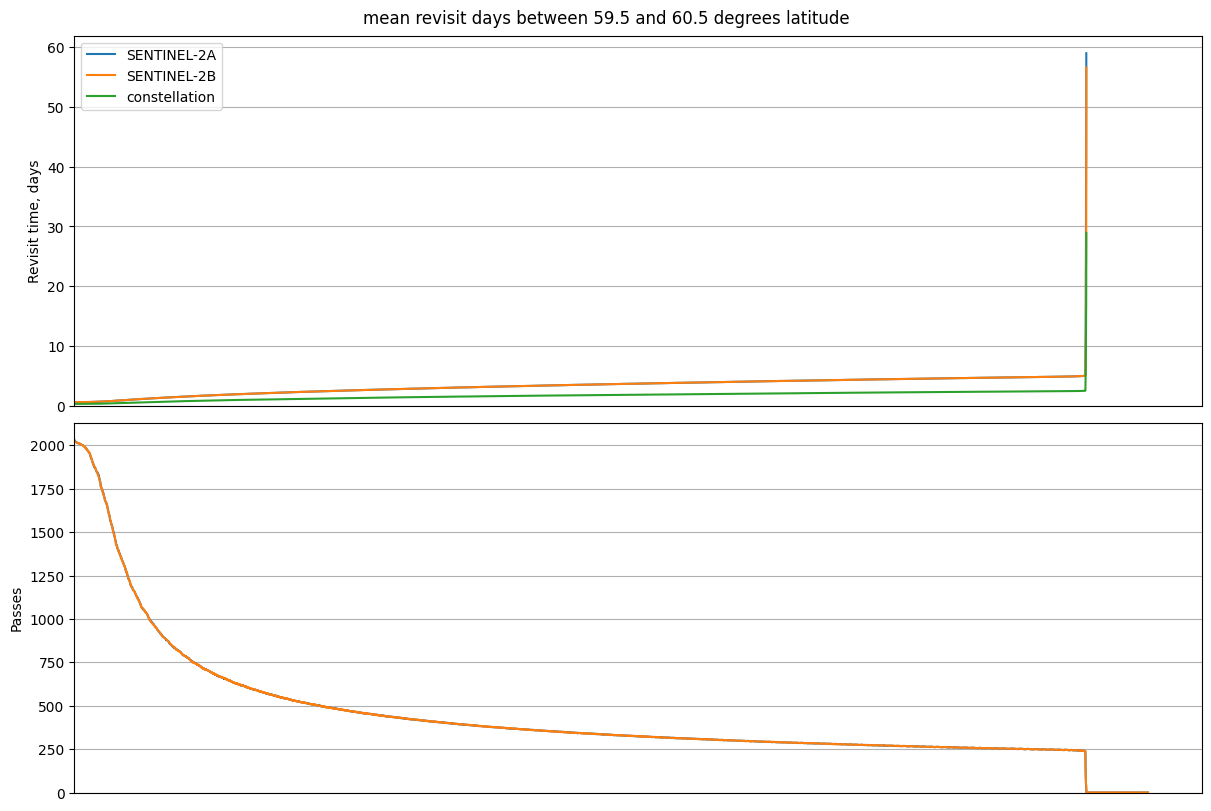

In [21]:
# Plot by bin

lat_width = 1
lat_centre = 60
min_lat = lat_centre - 0.5 * lat_width
max_lat = lat_centre + 0.5 * lat_width
mask = ~ ((grid.lons_deg > max_lat) | (grid.lats_deg < min_lat))

fig, ax = plt.subplots(2, 1, sharex=True, figsize=(12, 8), layout="compressed")
for name, data, data2 in zip([sats.sats[0].name, sats.sats[1].name, "constellation"], [coverage.mean_revisit_days[0], coverage.mean_revisit_days[1], coverage.constellation_mean_revisit_days], [coverage.passes[0], coverage.passes[1], None]):
    order = np.argsort(data[mask])
    y_data = data[mask][order]
    x_data = np.arange(len(y_data))
    ax[0].plot(x_data, y_data, label=name)

    if data2 is not None:
        y_data2 = data2[mask][order]
        ax[1].plot(x_data, y_data2, label=name)
ax[0].legend()
ax[0].set_xlim(0, None)
ax[0].set_ylim(0, None)
ax[0].set_xticks([])
ax[0].set_ylabel("Revisit time, days")
ax[0].grid()
ax[1].set_xlim(0, None)
ax[1].set_ylim(0, None)
ax[1].set_xticks([])
ax[1].set_ylabel("Passes")
ax[1].grid()
_ = fig.suptitle(f"mean revisit days between {min_lat} and {max_lat} degrees latitude")

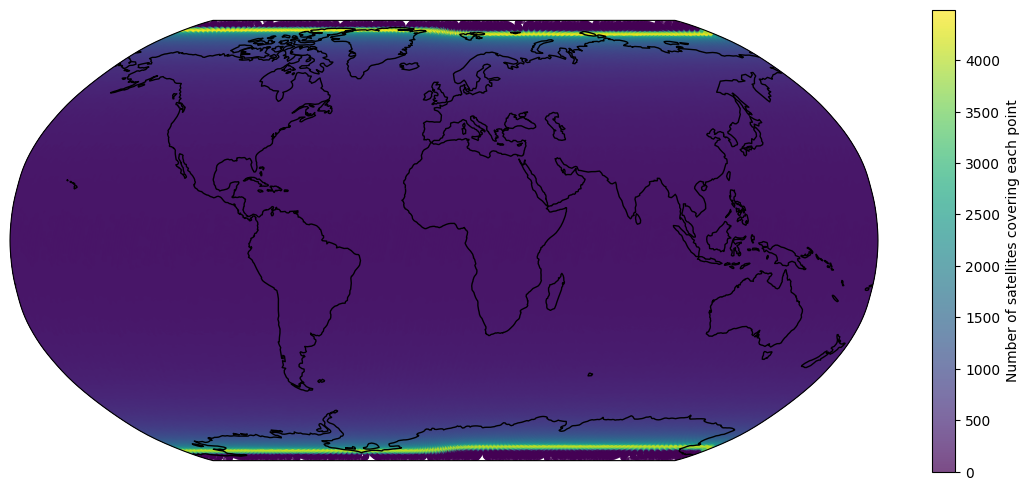

<module 'matplotlib.pyplot' from 'C:\\Users\\rufus\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python310\\site-packages\\matplotlib\\pyplot.py'>

In [22]:
# Plot coverage

coverage.plot_coverage()

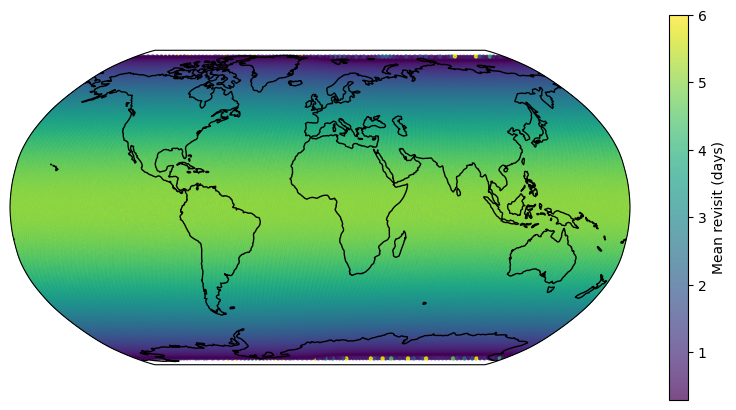

<module 'matplotlib.pyplot' from 'C:\\Users\\rufus\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python310\\site-packages\\matplotlib\\pyplot.py'>

In [23]:
# Plot mean revisit time

coverage.plot_mean_revisit_days(vmax=6)

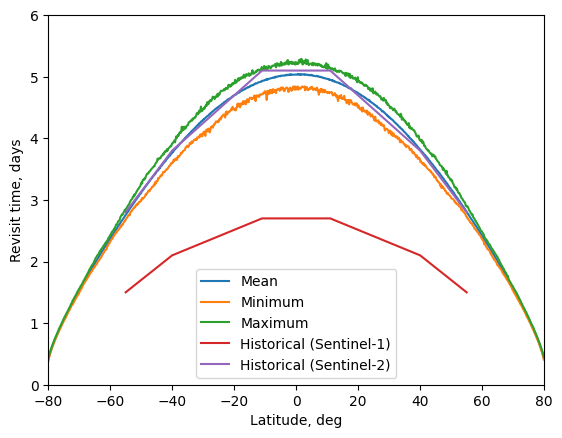

In [29]:
# plot mean revisit time vs latitude

plt = coverage.plot_mean_revisit_time_vs_latitude(show=False, lat_min_deg=-80, lat_max_deg=80, trim_lower_percentile=0, trim_upper_percentile=100)

plt.plot([-55, -40, -11, 0, 11, 40, 55], [1.5, 2.1, 2.7, 2.7, 2.7, 2.1, 1.5], label="Historical (Sentinel-1)")
plt.plot([-55, -40, -11, 0, 11, 40, 55], [2.8, 3.8, 5.1, 5.1, 5.1, 3.8, 2.8], label="Historical (Sentinel-2)")
plt.legend()
plt.ylim(0, 6)
plt.grid(False)
plt.show()

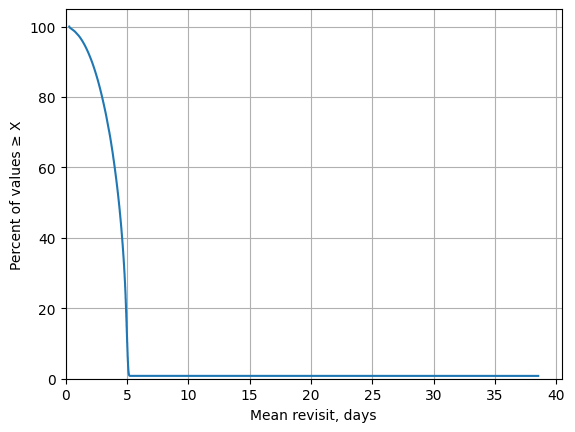

In [25]:
# plot mean revisit days reverse CDF

plt = coverage.plot_mean_revisit_days_reverse_CDF()